# 🏠 Colombo Residential House Price Predictor: Data Cleaning, EDA & Modelling

End-to-end notebook behind the [Streamlit app](https://colombo-house-price-predictor-dduvq7fareregvlahx6wwn.streamlit.app/).

**Pipeline**
1. Clean the raw scraped Ikman.lk listings (`colombo.csv`, not included in the repo)
2. Remove unrealistic records and per-location price outliers
3. Explore the data (EDA)
4. Model experiments: Random Forest, then XGBoost, with feature engineering and a log-transformed target
5. Fair evaluation on a held-out test set against simple baselines, plus 5-fold cross-validation

> **Note:** prices are online **asking prices**, not final sale prices.

In [1]:
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, make_scorer)
from xgboost import XGBRegressor

## 0. Helper functions
Shared by all experiments so every model is built and scored the same way.

In [2]:
NUM_BASIC = ['Land_Perches', 'Bedrooms', 'Bathrooms']
NUM_ENGINEERED = NUM_BASIC + ['Total_Rooms', 'Bath_Bed_Ratio']


def add_features(data):
    """Add engineered features (must be identical at training and prediction time)."""
    data = data.copy()
    data['Total_Rooms'] = data['Bedrooms'] + data['Bathrooms']
    data['Bath_Bed_Ratio'] = data['Bathrooms'] / (data['Bedrooms'] + 1e-5)  # 1e-5 avoids division by zero
    return data


def make_preprocessor(numeric_cols):
    """Scale numeric columns and one-hot encode Location."""
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Location']),
    ])


def print_scores(title, y_true, y_pred):
    """y_true and y_pred must both be in LKR (original price scale)."""
    print(f"=== {title} ===")
    print(f"R² Score : {r2_score(y_true, y_pred):.4f}")
    print(f"MAE      : LKR {mean_absolute_error(y_true, y_pred):,.0f}")

## 1. Data cleaning
The raw scrape contains a listing URL, a heading, a details string and a price. From these we extract
**Location**, **Land size (perches)**, **Bedrooms**, **Bathrooms** and **Price (LKR)**.
Location is resolved by keyword matching against the URL and heading (specific Colombo postal zones and
surrounding suburbs).

In [3]:
# Load the raw scraped dataset
df = pd.read_csv('colombo.csv')

# Identify the relevant columns by name pattern
url_col = [c for c in df.columns if 'card-link' in c or 'href' in c][0]
heading_col = [c for c in df.columns if 'heading' in c or 'title' in c][0]
details_col = [c for c in df.columns if 'details' in c][0]
price_col = [c for c in df.columns if 'price' in c][0]

# Keyword mapping: specific Colombo postal zones and suburbs
location_mapping = {
    # Central Colombo (postal zones)
    'Colombo 01': ['colombo 01', 'colombo 1', 'fort'],
    'Colombo 02': ['colombo 02', 'colombo 2', 'slave island'],
    'Colombo 03': ['colombo 03', 'colombo 3', 'kollupitiya', 'colpetty'],
    'Colombo 04': ['colombo 04', 'colombo 4', 'bambalapitiya'],
    'Colombo 05': ['colombo 05', 'colombo 5', 'havelock', 'kirulapone'],
    'Colombo 06': ['colombo 06', 'colombo 6', 'wellawatte', 'pamankada'],
    'Colombo 07': ['colombo 07', 'colombo 7', 'cinnamon gardens', 'torrington'],
    'Colombo 08': ['colombo 08', 'colombo 8', 'borella', 'boralla'],
    'Colombo 09': ['colombo 09', 'colombo 9', 'dematagoda'],
    'Colombo 10': ['colombo 10', 'maradana'],
    'Colombo 11': ['colombo 11', 'pettah'],
    'Colombo 12': ['colombo 12', 'hulftsdorp'],
    'Colombo 13': ['colombo 13', 'kotahena'],
    'Colombo 14': ['colombo 14', 'grandpass'],
    'Colombo 15': ['colombo 15', 'mutwal', 'modara'],

    # Suburbs and catchment areas
    'Piliyandala': ['piliyandala', 'piliyadnala', 'dampe', 'kasbawa', 'kesbewa', 'kindelpitiya', 'kahathuduwa', 'piliyan', 'suwarapola'],
    'Athurugiriya': ['athurugiriya', 'aturugiriya', 'habarakada', 'korathota'],
    'Kottawa': ['kottawa', 'kottttaav', 'kottaaven', 'makumbura', 'siddamulla'],
    'Homagama': ['homagama', 'hoomaagm', 'diyagama', 'godagama', 'goddgmin', 'meegoda', 'pitipana', 'panagoda'],
    'Mattegoda': ['mattegoda', 'mttegodd'],
    'Boralesgamuwa': ['boralesgamuwa', 'borlsgmuv', 'bellanwila', 'rattanapitiya'],
    'Battaramulla': ['battaramulla', 'pelawatta', 'pelawatte', 'koswatte', 'thalahena', 'subhuthipura'],
    'Thalawathugoda': ['thalawathugoda', 'thalapathpitiya', 'kalalgoda', 'hokandara'],
    'Malabe': ['malabe', 'maalbee', 'kaduwela', 'arangala'],
    'Pannipitiya': ['pannipitiya', 'depanama', 'weera mawatha', 'christopher', 'liyanagoda', 'batuwandara'],
    'Maharagama': ['maharagama', 'navinna', 'pamunuwa', 'godigamuwa'],
    'Nugegoda': ['nugegoda', 'delkanda', 'mirihana', 'gangodawila', 'jambugasmulla', 'kohuwala'],
    'Dehiwala': ['dehiwala', 'kalubowila', 'attidiya', 'bellanthota'],
    'Mount Lavinia': ['mount lavinia', 'mt lavinia', 'ratmalana', 'rawatawatta'],
    'Sri Jayawardenepura Kotte': ['kotte', 'pitakotte', 'ethul kotte', 'nawala', 'rajagiriya', 'welikada', 'madiwela'],
    'Moratuwa': ['moratuwa', 'katubadda', 'egoda uyana', 'angulana', 'lunawa'],
    'Wellampitiya': ['wellampitiya', 'kolonnawa', 'kotikawatta', 'mulleriyawa', 'angoda', 'gotatuwa']
}


def resolve_location(row):
    """Return the first location whose keyword appears in the listing URL/heading."""
    text = f"{str(row[url_col])} {str(row[heading_col])}".lower().replace('-', ' ')
    for main_loc, keywords in location_mapping.items():
        for kw in keywords:
            if re.search(rf'\b{re.escape(kw)}\b', text):
                return main_loc
    return 'Other Colombo'


df['Location'] = df.apply(resolve_location, axis=1)


# Parsing helpers
def get_perches(heading):
    if pd.isna(heading): return None
    match = re.search(r'([\d\.]+)\s*(?:P|Perch|Perches)', str(heading), re.IGNORECASE)
    return float(match.group(1)) if match else None

def get_beds(details):
    match = re.search(r'Bedrooms:\s*(\d+)', str(details))
    return int(match.group(1)) if match else None

def get_baths(details):
    match = re.search(r'Bathrooms:\s*(\d+)', str(details))
    return int(match.group(1)) if match else None

def clean_price(price):
    if pd.isna(price): return None
    cleaned = re.sub(r'[^\d.]', '', str(price))
    return float(cleaned) if cleaned else None


df['Land_Perches'] = df[heading_col].apply(get_perches)
df['Bedrooms'] = df[details_col].apply(get_beds)
df['Bathrooms'] = df[details_col].apply(get_baths)
df['Price_LKR'] = df[price_col].apply(clean_price)

# Keep only the modelling columns; price, bedrooms and bathrooms are required
cleaned_df = df[['Location', 'Land_Perches', 'Bedrooms', 'Bathrooms', 'Price_LKR']].copy()
cleaned_df.dropna(subset=['Price_LKR', 'Bedrooms', 'Bathrooms'], inplace=True)

# Impute missing land size with the median of the same location (fallback: overall median)
cleaned_df['Land_Perches'] = cleaned_df.groupby('Location')['Land_Perches'].transform(lambda x: x.fillna(x.median()))
cleaned_df['Land_Perches'] = cleaned_df['Land_Perches'].fillna(cleaned_df['Land_Perches'].median())

cleaned_df.to_csv('colombo_houses_cleaned_final.csv', index=False)

print("Location distribution:")
print(cleaned_df['Location'].value_counts())

Location distribution:
Location
Colombo 01                   314
Other Colombo                254
Piliyandala                  244
Colombo 02                   157
Colombo 03                   134
Malabe                       104
Sri Jayawardenepura Kotte     92
Athurugiriya                  92
Nugegoda                      90
Battaramulla                  83
Colombo 05                    75
Thalawathugoda                75
Wellampitiya                  72
Colombo 04                    69
Homagama                      68
Colombo 06                    57
Dehiwala                      54
Maharagama                    52
Kottawa                       50
Colombo 07                    48
Colombo 10                    41
Mount Lavinia                 36
Pannipitiya                   34
Colombo 08                    33
Colombo 09                    33
Boralesgamuwa                 29
Moratuwa                      28
Colombo 11                    25
Mattegoda                     20
Colombo 12 

## 2. Removing unrealistic records and outliers
1. Price outside **LKR 5M – 500M**
2. Bedrooms or bathrooms outside **1 – 10**
3. Per-location outliers: prices more than **2 standard deviations** from the mean of their own location

> ⚠️ Missing land sizes were filled with the location median in step 1, so many rows share the same
> `Land_Perches` value. Treat this feature with some caution.

In [4]:
df = pd.read_csv('colombo_houses_cleaned_final.csv')

# 1. Remove extreme prices (below LKR 5M or above LKR 500M)
df = df[(df['Price_LKR'] >= 5_000_000) & (df['Price_LKR'] <= 500_000_000)]

# 2. Realistic bedroom / bathroom counts (1-10)
df = df[(df['Bedrooms'] >= 1) & (df['Bedrooms'] <= 10)]
df = df[(df['Bathrooms'] >= 1) & (df['Bathrooms'] <= 10)]


# 3. Per-location price outliers: keep prices within mean ± 2 standard deviations of the location
def remove_price_outliers(data):
    parts = []
    for _, subdf in data.groupby('Location'):
        m = np.mean(subdf['Price_LKR'])
        st = np.std(subdf['Price_LKR'])
        parts.append(subdf[(subdf['Price_LKR'] >= m - 2 * st) & (subdf['Price_LKR'] <= m + 2 * st)])
    return pd.concat(parts, ignore_index=True)


final_df = remove_price_outliers(df)
final_df.to_csv('colombo_houses_model_ready.csv', index=False)

print(f"Rows before per-location outlier removal: {len(df)}")
print(f"Rows after per-location outlier removal : {len(final_df)}")
print("Model-ready dataset saved to colombo_houses_model_ready.csv")

Rows before per-location outlier removal: 2513
Rows after per-location outlier removal : 2392
Model-ready dataset saved to colombo_houses_model_ready.csv


## 3. Dataset overview

In [5]:
df = pd.read_csv('colombo_houses_model_ready.csv')

print("--- Sample rows ---")
print(df.head(10))

print("\n--- Dataset info ---")
df.info()

print("\n--- Numerical summary ---")
pd.set_option('display.float_format', lambda x: '%.2f' % x)  # readable numbers
print(df.describe())

print("\n--- Top 10 locations by number of listings ---")
print(df['Location'].value_counts().head(10))

--- Sample rows ---
       Location  Land_Perches  Bedrooms  Bathrooms   Price_LKR
0  Athurugiriya          10.5         4          3  25000000.0
1  Athurugiriya          10.5         3          2  22500000.0
2  Athurugiriya          10.5         4          3  35500000.0
3  Athurugiriya          10.5         3          1  40000000.0
4  Athurugiriya          10.5         3          2  38500000.0
5  Athurugiriya          10.5         3          2  31000000.0
6  Athurugiriya          10.5         3          3  40000000.0
7  Athurugiriya          10.5         3          2  27500000.0
8  Athurugiriya          10.5         4          3  25000000.0
9  Athurugiriya          10.5         3          2  28500000.0

--- Dataset info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      2392 non-null   object 
 1   Land_Perches  2392 non-nu

## 4. Exploratory data analysis
Note: a few listings report thousands of perches (likely data-entry errors or large land parcels).
The land-size scatter plot below is limited to ≤ 100 perches **for readability only**; the model data is unchanged.

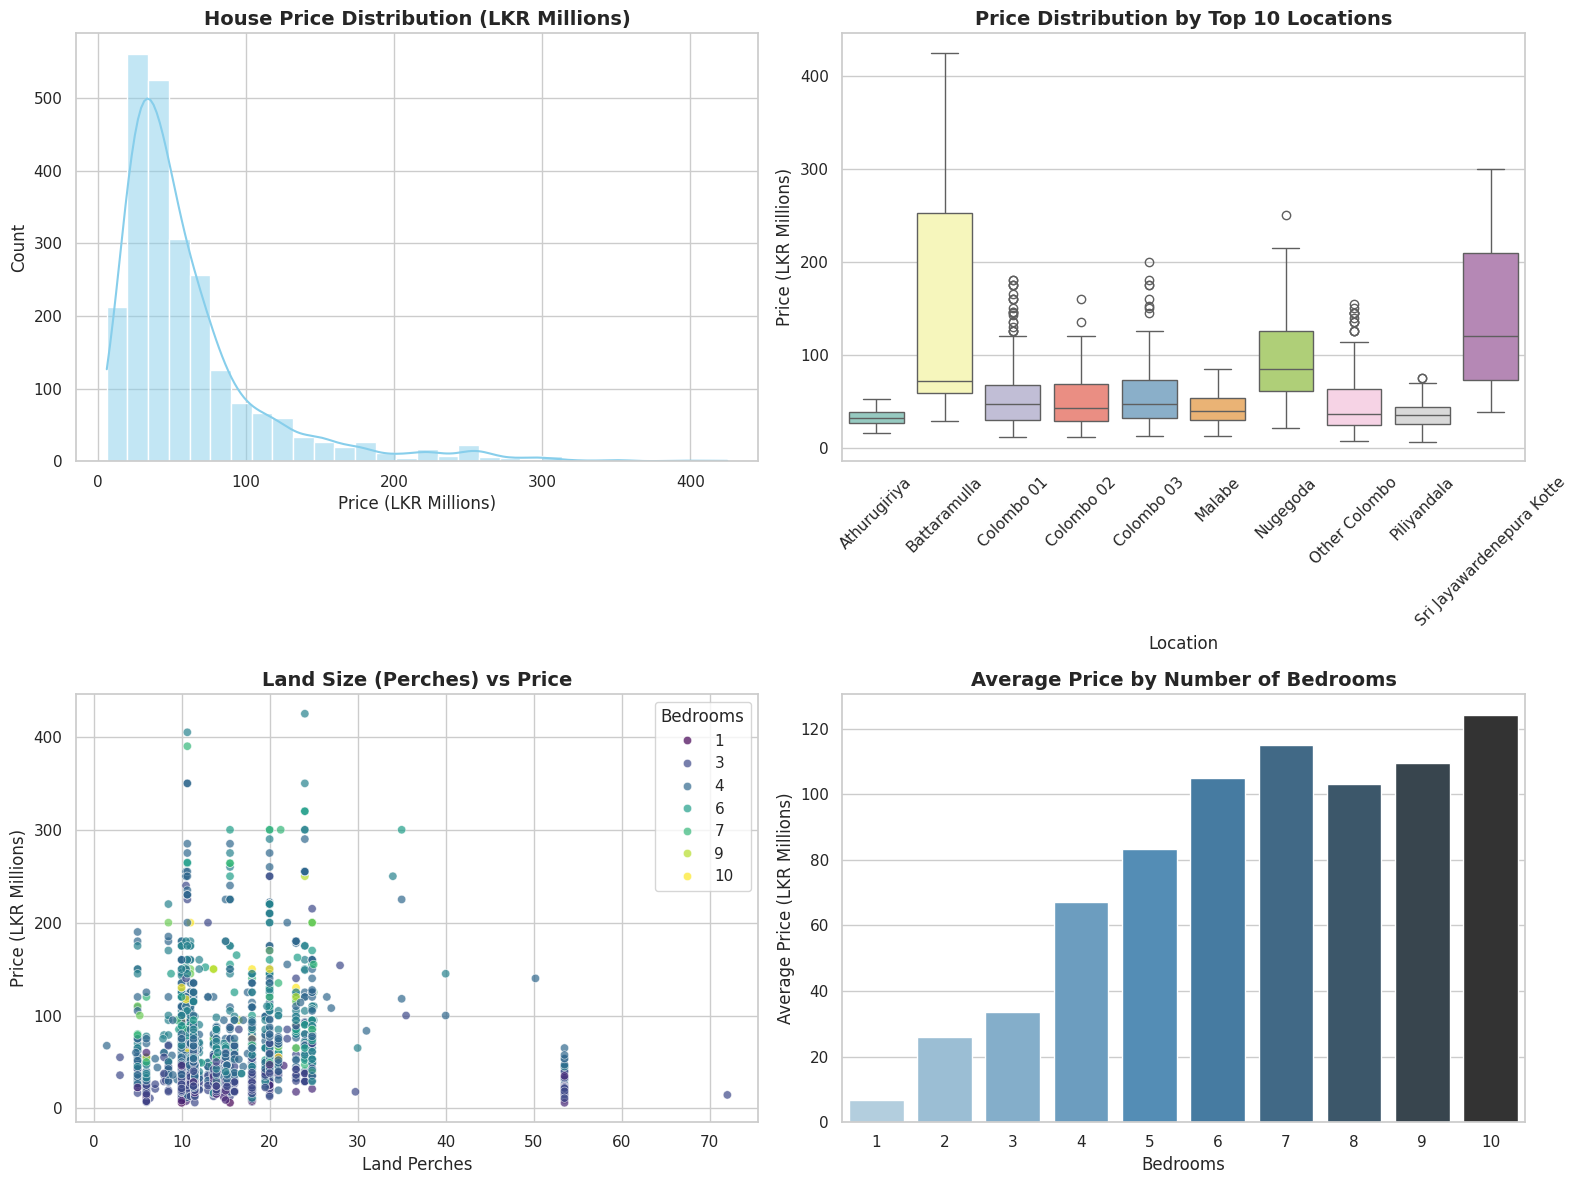

In [6]:
df = pd.read_csv('colombo_houses_model_ready.csv')
df['Price_M'] = df['Price_LKR'] / 1e6  # price in LKR millions

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Price distribution
plt.subplot(2, 2, 1)
sns.histplot(df['Price_M'], kde=True, color='skyblue', bins=30)
plt.title('House Price Distribution (LKR Millions)', fontsize=14, fontweight='bold')
plt.xlabel('Price (LKR Millions)')
plt.ylabel('Count')

# 2. Price by top 10 locations
plt.subplot(2, 2, 2)
top_locations = df['Location'].value_counts().head(10).index
df_top_loc = df[df['Location'].isin(top_locations)]
sns.boxplot(data=df_top_loc, x='Location', y='Price_M', hue='Location', palette='Set3', legend=False)
plt.title('Price Distribution by Top 10 Locations', fontsize=14, fontweight='bold')
plt.xlabel('Location')
plt.ylabel('Price (LKR Millions)')
plt.xticks(rotation=45)

# 3. Land size vs price (plot limited to <= 100 perches for readability)
plt.subplot(2, 2, 3)
sns.scatterplot(data=df[df['Land_Perches'] <= 100], x='Land_Perches', y='Price_M',
                hue='Bedrooms', palette='viridis', alpha=0.7)
plt.title('Land Size (Perches) vs Price', fontsize=14, fontweight='bold')
plt.xlabel('Land Perches')
plt.ylabel('Price (LKR Millions)')

# 4. Average price by number of bedrooms
plt.subplot(2, 2, 4)
avg_price_bed = df.groupby('Bedrooms')['Price_M'].mean()
sns.barplot(x=avg_price_bed.index, y=avg_price_bed.values, hue=avg_price_bed.index,
            palette='Blues_d', legend=False)
plt.title('Average Price by Number of Bedrooms', fontsize=14, fontweight='bold')
plt.xlabel('Bedrooms')
plt.ylabel('Average Price (LKR Millions)')

plt.tight_layout()
plt.show()

## 5. Model experiments
Each step adds one idea. Scores below are on a held-out 20% test split (`random_state=42`), in LKR.
Steps 5.1–5.3 use the full price range (5M–500M); 5.4 restricts to the mid-range market.

### 5.1 Baseline Random Forest (raw price, basic features)

In [7]:
df = pd.read_csv('colombo_houses_model_ready.csv')

X = df[['Location'] + NUM_BASIC]
y = df['Price_LKR']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_basic = Pipeline(steps=[
    ('preprocessor', make_preprocessor(NUM_BASIC)),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

print("Training model...")
rf_basic.fit(X_train, y_train)
print_scores("Random Forest, basic features", y_test, rf_basic.predict(X_test))

Training model...
=== Random Forest, basic features ===
R² Score : 0.3930
MAE      : LKR 23,099,628


### 5.2 Random Forest + feature engineering + log-transformed price
The log transform reduces the influence of very expensive houses. Predictions are converted back with `np.expm1`.

In [8]:
df = pd.read_csv('colombo_houses_model_ready.csv')
df = add_features(df)

X = df[['Location'] + NUM_ENGINEERED]
y = np.log1p(df['Price_LKR'])  # log-transformed target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_opt = Pipeline(steps=[
    ('preprocessor', make_preprocessor(NUM_ENGINEERED)),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5, random_state=42))
])
rf_opt.fit(X_train, y_train)

# Convert both predictions and actual values back to LKR before scoring
print_scores("Random Forest, engineered features + log target",
             np.expm1(y_test), np.expm1(rf_opt.predict(X_test)))

=== Random Forest, engineered features + log target ===
R² Score : 0.4269
MAE      : LKR 21,754,003


### 5.3 XGBoost (same features, log target)

In [9]:
xgb_v1 = Pipeline(steps=[
    ('preprocessor', make_preprocessor(NUM_ENGINEERED)),
    ('regressor', XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    ))
])
xgb_v1.fit(X_train, y_train)  # same split as 5.2
print_scores("XGBoost, full price range", np.expm1(y_test), np.expm1(xgb_v1.predict(X_test)))

=== XGBoost, full price range ===
R² Score : 0.4619
MAE      : LKR 21,255,548


### 5.4 Floor-area check
Floor area (sq ft) would likely improve accuracy, but very few listings mention it, so it cannot be used as a feature.

In [10]:
raw = pd.read_csv('colombo.csv')
text_col = [c for c in raw.columns if 'details' in c or 'description' in c or 'heading' in c][0]


def extract_sqft(text):
    """Extract floor area from patterns like '1500 sqft', '2,000 sq ft', '1800 sq.ft'."""
    if pd.isna(text): return None
    match = re.search(r'([\d,]+)\s*(?:sqft|sq\.?\s*ft|square\s*feet)', str(text), re.IGNORECASE)
    if match:
        try:
            val = float(match.group(1).replace(',', ''))
            if 300 <= val <= 20000:  # realistic bounds
                return val
        except ValueError:
            return None
    return None


raw['Sqft'] = raw[text_col].apply(extract_sqft)
print(f"Total rows: {len(raw)}")
print(f"Rows with floor area extracted: {raw['Sqft'].notna().sum()}")

Total rows: 2520
Rows with floor area extracted: 3


### 5.5 Final model: XGBoost on the mid-range market (LKR 5M – 150M)
Very expensive luxury properties are rare and behave differently, so the final model focuses on the mid-range market.
Predictions outside this range are unreliable.

In [11]:
def build_xgb_pipeline():
    return Pipeline(steps=[
        ('preprocessor', make_preprocessor(NUM_ENGINEERED)),
        ('regressor', XGBRegressor(
            n_estimators=400, learning_rate=0.03, max_depth=5,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        ))
    ])


df = pd.read_csv('colombo_houses_model_ready.csv')
df_mid = add_features(df[(df['Price_LKR'] >= 5_000_000) & (df['Price_LKR'] <= 150_000_000)])

X = df_mid[['Location'] + NUM_ENGINEERED]
y = np.log1p(df_mid['Price_LKR'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_final = build_xgb_pipeline()
xgb_final.fit(X_train, y_train)

print(f"Rows used: {len(df_mid)}")
print_scores("Final XGBoost (mid-range market)", np.expm1(y_test), np.expm1(xgb_final.predict(X_test)))

joblib.dump(xgb_final, 'colombo_house_price_final_xgb.pkl')
print("\nModel saved as 'colombo_house_price_final_xgb.pkl'")

Rows used: 2248
=== Final XGBoost (mid-range market) ===
R² Score : 0.4935
MAE      : LKR 14,121,363

Model saved as 'colombo_house_price_final_xgb.pkl'


## 6. Sample predictions

In [12]:
model = joblib.load('colombo_house_price_final_xgb.pkl')


def predict_house_price(location, land_perches, bedrooms, bathrooms):
    """Return the estimated price in LKR."""
    input_data = add_features(pd.DataFrame([{
        'Location': location,
        'Land_Perches': float(land_perches),
        'Bedrooms': int(bedrooms),
        'Bathrooms': int(bathrooms),
    }]))
    predicted_log = model.predict(input_data[['Location'] + NUM_ENGINEERED])[0]
    return np.expm1(predicted_log)


test_houses = [
    {'location': 'Piliyandala',    'perches': 10, 'beds': 3, 'baths': 2},
    {'location': 'Colombo 03',     'perches': 8,  'beds': 4, 'baths': 3},
    {'location': 'Thalawathugoda', 'perches': 12, 'beds': 4, 'baths': 3},
]

print("=== Sample predictions ===")
for h in test_houses:
    price = predict_house_price(h['location'], h['perches'], h['beds'], h['baths'])
    print(f"Location: {h['location']:<15} | {h['perches']} perches | {h['beds']} bed | {h['baths']} bath")
    print(f"Estimated price: LKR {price:,.0f} (about LKR {price / 1e6:.1f} million)\n")

=== Sample predictions ===
Location: Piliyandala     | 10 perches | 3 bed | 2 bath
Estimated price: LKR 26,238,812 (about LKR 26.2 million)

Location: Colombo 03      | 8 perches | 4 bed | 3 bath
Estimated price: LKR 55,043,540 (about LKR 55.0 million)

Location: Thalawathugoda  | 12 perches | 4 bed | 3 bath
Estimated price: LKR 61,387,004 (about LKR 61.4 million)



## 7. Fair evaluation: held-out test set, baselines and cross-validation

Every model below is trained on the **same training rows** and scored on the **same unseen test rows**
(mid-range market, LKR 5M – 150M).

**Metrics** (all in LKR, original price scale)
- **R²**: share of price variation explained
- **MAE / RMSE**: typical error in LKR (RMSE penalises large errors more)
- **MAPE / Median APE**: error as a % of the true price. Median APE is less affected by a few very cheap listings.

**Baselines** answer the question *"is the model better than a trivial guess?"*
- *Overall median*: predict the median training price for every house
- *Location median*: predict the median training price of the house's location

> Only scores computed on unseen test data should be reported. Scores computed on the full dataset include the
> training rows and look better than they really are.

In [13]:
def report(name, y_true, y_pred):
    """Metrics on the original LKR scale."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ape = np.abs(y_true - y_pred) / y_true * 100
    return {
        'Model': name,
        'R²': round(r2_score(y_true, y_pred), 3),
        'MAE (LKR M)': round(mean_absolute_error(y_true, y_pred) / 1e6, 2),
        'RMSE (LKR M)': round(np.sqrt(mean_squared_error(y_true, y_pred)) / 1e6, 2),
        'MAPE (%)': round(ape.mean(), 1),
        'Median APE (%)': round(np.median(ape), 1),
    }


# Same mid-range data and split as the final model (same random_state)
data = add_features(df[(df['Price_LKR'] >= 5_000_000) & (df['Price_LKR'] <= 150_000_000)])
X = data[['Location'] + NUM_ENGINEERED]
price = data['Price_LKR']
X_train, X_test, price_train, price_test = train_test_split(X, price, test_size=0.2, random_state=42)

# --- Baselines ---
overall_median = price_train.median()
pred_overall = np.full(len(price_test), overall_median)

location_median = price_train.groupby(X_train['Location']).median()
pred_location = X_test['Location'].map(location_median).fillna(overall_median).to_numpy()

# --- Models (trained on log price, predictions converted back to LKR) ---
log_train = np.log1p(price_train)

rf = Pipeline(steps=[
    ('preprocessor', make_preprocessor(NUM_ENGINEERED)),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5, random_state=42))
])
rf.fit(X_train, log_train)
pred_rf = np.expm1(rf.predict(X_test))

xgb = build_xgb_pipeline()
xgb.fit(X_train, log_train)
pred_xgb = np.expm1(xgb.predict(X_test))

results = pd.DataFrame([
    report('Baseline: overall median', price_test, pred_overall),
    report('Baseline: location median', price_test, pred_location),
    report('Random Forest', price_test, pred_rf),
    report('XGBoost (final)', price_test, pred_xgb),
])

print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}\n")
print(results.to_string(index=False))

Train rows: 1798 | Test rows: 450

                    Model    R²  MAE (LKR M)  RMSE (LKR M)  MAPE (%)  Median APE (%)
 Baseline: overall median -0.06        21.49         29.50     49.20           37.10
Baseline: location median  0.16        18.74         26.31     42.70           32.20
            Random Forest  0.46        14.44         21.09     29.50           23.00
          XGBoost (final)  0.49        14.12         20.43     29.00           23.50


### 7.1 5-fold cross-validation (XGBoost)
A single train/test split can be lucky or unlucky. Cross-validation repeats the evaluation on 5 different splits.

In [14]:
def mae_lkr(y_true_log, y_pred_log):
    return mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log))

def r2_lkr(y_true_log, y_pred_log):
    return r2_score(np.expm1(y_true_log), np.expm1(y_pred_log))


kf = KFold(n_splits=5, shuffle=True, random_state=42)
log_price = np.log1p(price)

cv_mae = -cross_val_score(build_xgb_pipeline(), X, log_price, cv=kf,
                          scoring=make_scorer(mae_lkr, greater_is_better=False))
cv_r2 = cross_val_score(build_xgb_pipeline(), X, log_price, cv=kf,
                        scoring=make_scorer(r2_lkr))

print(f"5-fold CV MAE: LKR {cv_mae.mean():,.0f} ± {cv_mae.std():,.0f}")
print(f"5-fold CV R² : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

5-fold CV MAE: LKR 14,380,334 ± 273,965
5-fold CV R² : 0.479 ± 0.042


## 8. Limitations and next steps
- Prices are **asking prices** from online listings, not final sale prices.
- **Floor area** and property age/condition strongly affect price but are not available for almost all listings.
- Many listings had no land size, which was **imputed with the location median**; rows share that value.
- Locations are matched by keyword and some listings fall into **"Other Colombo"**.
- The model is trained on **LKR 5M – 150M** only, so luxury and very cheap properties are out of scope.
- Next steps: check for duplicate listings, add a "land size was missing" flag, tune hyperparameters, and try finer
  location features (e.g., distance to the city centre).